Device: cuda
Số ảnh train: 50000, test: 10000
Kích thước ảnh CIFAR-10: 32x32x3

CÂU 1: Train 10 epochs trên CIFAR-10

Cấu trúc model:
CIFAR10_CNN_Simple(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 620,362
Epoch 1/10  train_loss=1.3381  train_acc=51.18%  test_loss=1.0667  test_acc=62.46%
Epoch 2/10  train_loss=0.9393  train_acc=66.83%  test_loss=0.8847  test_acc=69.27%
Epoch 3/10  train_loss=0.7729  train_acc=72.81%  test_loss=0.7667  test_acc=73.33%
Epo

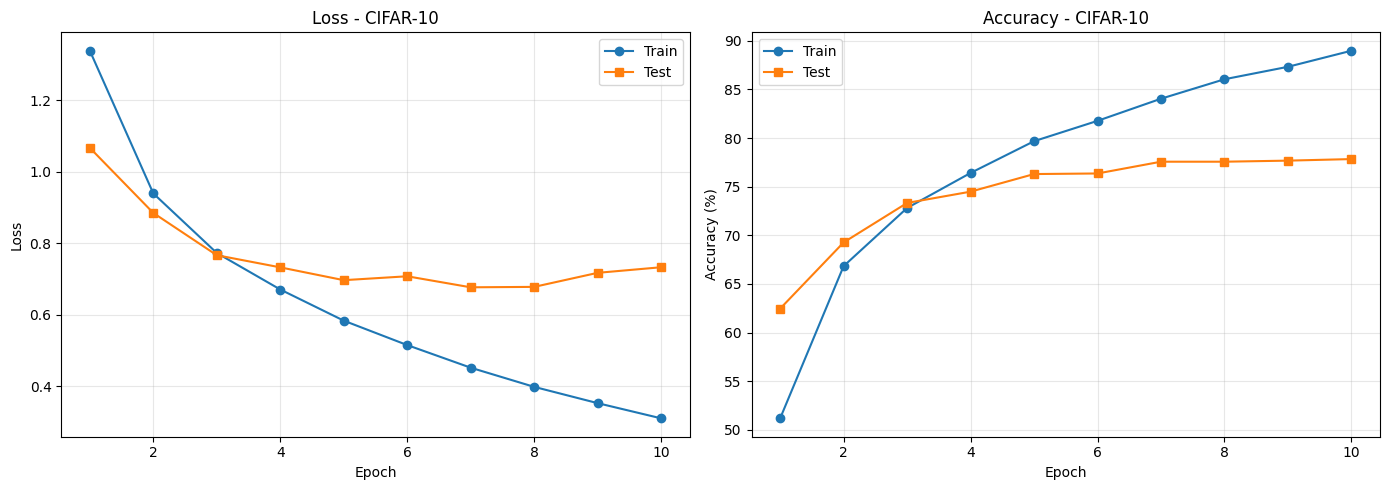


KẾT QUẢ CÂU 1 - CIFAR-10:
Test accuracy sau epoch 5: 76.30%
Test accuracy sau epoch 10: 77.84%
Chênh lệch: 1.54%
→ Khoảng cách train-test đang mở rộng, dấu hiệu OVERFITTING

CÂU 2: Model sâu hơn cho CIFAR-10
Tổng tham số model mới: 918,346
Epoch 1/10  train_loss=1.4662  train_acc=46.21%  test_loss=1.0879  test_acc=60.91%
Epoch 2/10  train_loss=1.0307  train_acc=63.33%  test_loss=0.8912  test_acc=68.68%
Epoch 3/10  train_loss=0.8562  train_acc=70.18%  test_loss=0.7854  test_acc=72.69%
Epoch 4/10  train_loss=0.7473  train_acc=73.84%  test_loss=0.7174  test_acc=75.05%
Epoch 5/10  train_loss=0.6757  train_acc=76.32%  test_loss=0.7720  test_acc=73.50%
Epoch 6/10  train_loss=0.6175  train_acc=78.49%  test_loss=0.7077  test_acc=75.89%
Epoch 7/10  train_loss=0.5666  train_acc=80.15%  test_loss=0.7133  test_acc=76.03%
Epoch 8/10  train_loss=0.5196  train_acc=81.76%  test_loss=0.6919  test_acc=77.12%
Epoch 9/10  train_loss=0.4899  train_acc=82.83%  test_loss=0.6748  test_acc=77.17%
Epoch 10/10 

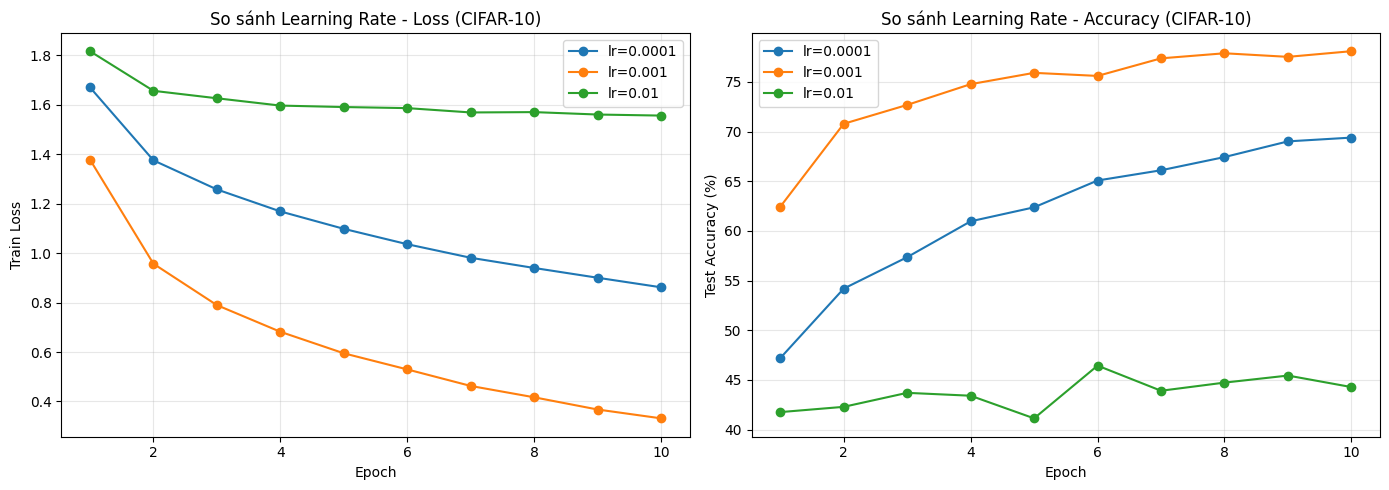


KẾT QUẢ CÂU 3:
lr=0.0001: Final test accuracy = 69.40%
lr=0.001: Final test accuracy = 78.10%
lr=0.01: Final test accuracy = 44.28%

CÂU 4: Trực quan Feature Maps trên CIFAR-10


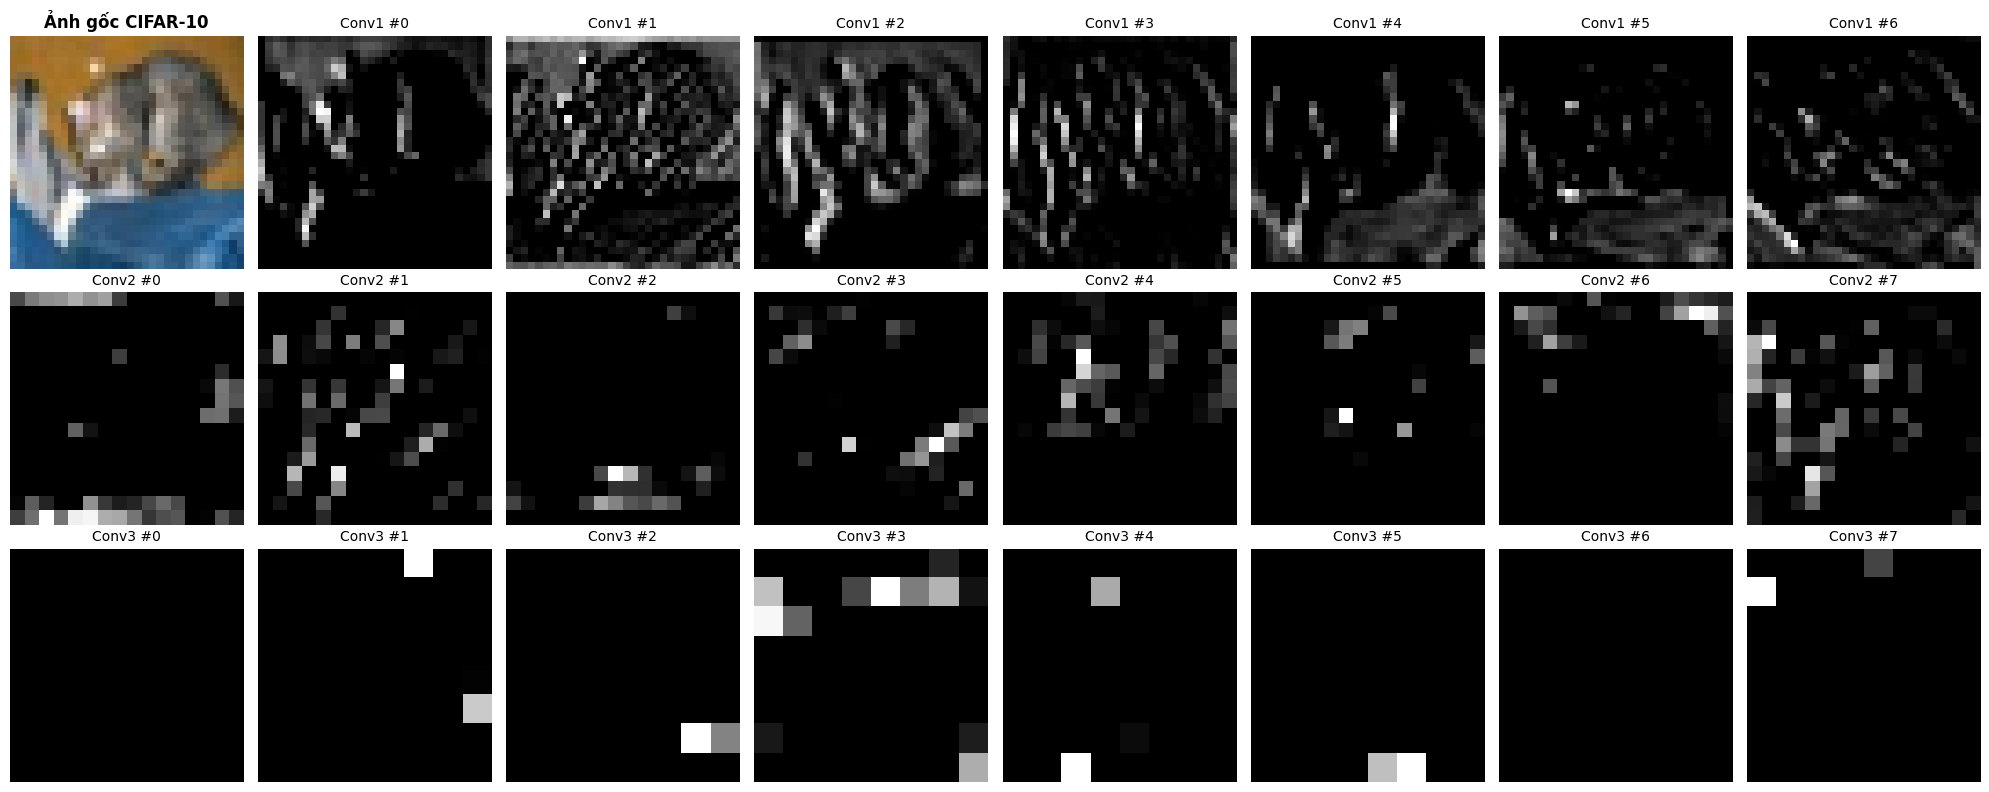


CÂU 5: Dropout + Data Augmentation trên CIFAR-10
Epoch 1/10  train_loss=1.5702  train_acc=42.77%  test_loss=1.1846  test_acc=56.74%
Epoch 2/10  train_loss=1.1978  train_acc=56.86%  test_loss=0.9933  test_acc=65.07%
Epoch 3/10  train_loss=1.0286  train_acc=63.52%  test_loss=0.8636  test_acc=69.83%
Epoch 4/10  train_loss=0.9268  train_acc=67.15%  test_loss=0.8369  test_acc=69.95%
Epoch 5/10  train_loss=0.8598  train_acc=69.82%  test_loss=0.7417  test_acc=74.37%
Epoch 6/10  train_loss=0.8120  train_acc=71.38%  test_loss=0.7433  test_acc=74.04%
Epoch 7/10  train_loss=0.7832  train_acc=72.46%  test_loss=0.7360  test_acc=74.84%
Epoch 8/10  train_loss=0.7498  train_acc=73.87%  test_loss=0.7060  test_acc=75.30%
Epoch 9/10  train_loss=0.7229  train_acc=74.56%  test_loss=0.6715  test_acc=76.73%
Epoch 10/10  train_loss=0.7107  train_acc=75.08%  test_loss=0.6624  test_acc=76.88%

KẾT QUẢ CÂU 5:
Model Dropout+Aug test accuracy: 76.88%

HIỂN THỊ ẢNH MẪU CIFAR-10


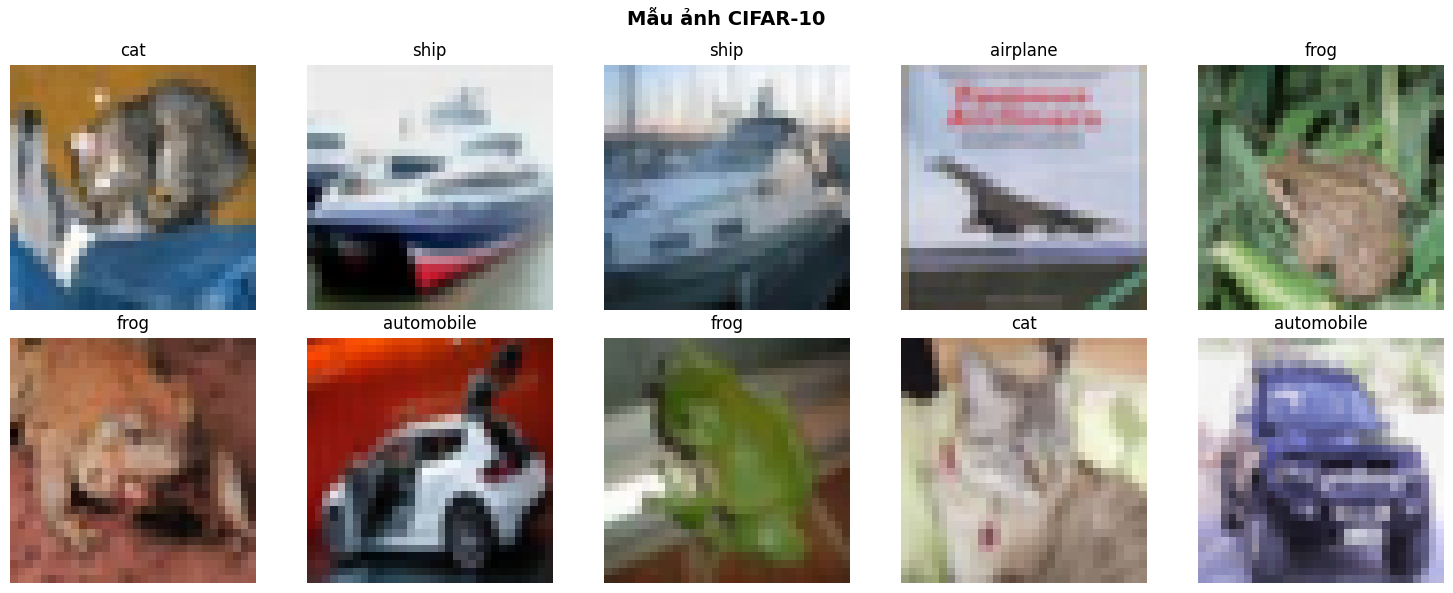

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from torchsummary import summary

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Cell 2: Chuẩn bị dữ liệu CIFAR-10
# CIFAR-10 mean và std cho từng channel (R, G, B)
# Mean: [0.4914, 0.4822, 0.4465], Std: [0.2470, 0.2435, 0.2616]
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616]),
])

# Tăng cường dữ liệu cho CIFAR-10
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Lật ngang ngẫu nhiên
    transforms.RandomCrop(32, padding=4),  # Cắt ngẫu nhiên
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Biến đổi màu sắc
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616]),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616]),
])

# Tải dữ liệu CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_base)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_base)

# Dataset với augmentation
train_dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                 download=True, transform=transform_train)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True, num_workers=2)

print(f'Số ảnh train: {len(train_dataset)}, test: {len(test_dataset)}')
print(f'Kích thước ảnh CIFAR-10: 32x32x3')

# Cell 3: Hàm đánh giá và huấn luyện
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, correct / total

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10):
    model.to(device)
    loss_history, acc_history = [], []
    test_loss_history, test_acc_history = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        loss_history.append(train_loss)
        acc_history.append(train_acc)
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)

        print(f'Epoch {epoch+1}/{num_epochs}  train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

    return loss_history, acc_history, test_loss_history, test_acc_history

# Cell 4: Định nghĩa Model CNN cho CIFAR-10
class CIFAR10_CNN_Base(nn.Module):
    """Model CNN cơ bản cho CIFAR-10 (tương tự MNIST nhưng điều chỉnh)"""
    def __init__(self):
        super().__init__()
        # Input: 3x32x32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32x32
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)         # 16x16

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 16x16
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)# 16x16
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)        # 8x8

        self.dropout = nn.Dropout(0.25)
        # Corrected: After conv4 + two pool operations, the size is 256 * 2 * 2 = 1024
        self.fc1 = nn.Linear(256 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, 10)
        self.dropout_fc = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))    # 32x32 -> 16x16
        x = self.pool(torch.relu(self.conv2(x)))    # 16x16 -> 8x8
        x = self.pool2(torch.relu(self.conv3(x)))   # 8x8 -> 4x4
        x = self.pool2(torch.relu(self.conv4(x)))   # 4x4 -> 2x2
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class CIFAR10_CNN_Simple(nn.Module):
    """Model CNN đơn giản hơn cho CIFAR-10"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32x32
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)         # 16x16

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 16x16
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)        # 8x8

        self.dropout = nn.Dropout(0.25)
        # Corrected: After conv3 and two pool operations, the size is 128 * 4 * 4 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))    # 32x32 -> 16x16
        x = self.pool2(torch.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = self.pool2(torch.relu(self.conv3(x)))   # 8x8 -> 4x4
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Cell 5: Câu 1 - Train với 10 epochs trên CIFAR-10
print("\n" + "="*70)
print("CÂU 1: Train 10 epochs trên CIFAR-10")
print("="*70)

model_c1 = CIFAR10_CNN_Simple()
criterion = nn.CrossEntropyLoss()
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=0.001)

# In cấu trúc model
print("\nCấu trúc model:")
print(model_c1)
n_params = sum(p.numel() for p in model_c1.parameters() if p.requires_grad)
print(f'Tổng tham số: {n_params:,}')

# Train 10 epochs
loss_c1, acc_c1, test_loss_c1, test_acc_c1 = train_model(
    model_c1, train_loader, test_loader, criterion, optimizer_c1, num_epochs=10
)

# Vẽ biểu đồ
epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, loss_c1, 'o-', label='Train')
axes[0].plot(epochs, test_loss_c1, 's-', label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Loss - CIFAR-10')

axes[1].plot(epochs, [a*100 for a in acc_c1], 'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_c1], 's-', label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy - CIFAR-10')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("KẾT QUẢ CÂU 1 - CIFAR-10:")
print(f"Test accuracy sau epoch 5: {test_acc_c1[4]*100:.2f}%")
print(f"Test accuracy sau epoch 10: {test_acc_c1[9]*100:.2f}%")
print(f"Chênh lệch: {test_acc_c1[9]*100 - test_acc_c1[4]*100:.2f}%")
if acc_c1[9] - test_acc_c1[9] > acc_c1[4] - test_acc_c1[4]:
    print("→ Khoảng cách train-test đang mở rộng, dấu hiệu OVERFITTING")
else:
    print("→ Khoảng cách train-test không mở rộng đáng kể")

# Cell 6: Câu 2 - Thêm tầng tích chập
print("\n" + "="*70)
print("CÂU 2: Model sâu hơn cho CIFAR-10")
print("="*70)

model_c2 = CIFAR10_CNN_Base()
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=0.001)

n_params_c2 = sum(p.numel() for p in model_c2.parameters() if p.requires_grad)
print(f"Tổng tham số model mới: {n_params_c2:,}")

loss_c2, acc_c2, test_loss_c2, test_acc_c2 = train_model(
    model_c2, train_loader, test_loader, criterion, optimizer_c2, num_epochs=10
)

# Cell 7: Câu 3 - Thay đổi learning rate
print("\n" + "="*70)
print("CÂU 3: So sánh Learning Rate trên CIFAR-10")
print("="*70)

learning_rates = [0.0001, 0.001, 0.01]
all_losses = {}
all_accs = {}

for lr in learning_rates:
    print(f"\n--- Training với lr = {lr} ---")
    model_temp = CIFAR10_CNN_Simple()
    optimizer_temp = optim.Adam(model_temp.parameters(), lr=lr)
    loss_temp, acc_temp, test_loss_temp, test_acc_temp = train_model(
        model_temp, train_loader, test_loader, criterion, optimizer_temp, num_epochs=10
    )
    all_losses[lr] = loss_temp
    all_accs[lr] = test_acc_temp

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr in learning_rates:
    axes[0].plot(range(1, 11), all_losses[lr], 'o-', label=f'lr={lr}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('So sánh Learning Rate - Loss (CIFAR-10)')

for lr in learning_rates:
    axes[1].plot(range(1, 11), [a*100 for a in all_accs[lr]], 'o-', label=f'lr={lr}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('So sánh Learning Rate - Accuracy (CIFAR-10)')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("KẾT QUẢ CÂU 3:")
for lr in learning_rates:
    print(f"lr={lr}: Final test accuracy = {all_accs[lr][9]*100:.2f}%")

# Cell 8: Câu 4 - Feature Maps Visualization
print("\n" + "="*70)
print("CÂU 4: Trực quan Feature Maps trên CIFAR-10")
print("="*70)

model_c1.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    conv1_out = torch.relu(model_c1.conv1(img))       # (1, 32, 32, 32)
    pool1_out = model_c1.pool(conv1_out)              # (1, 32, 16, 16)
    conv2_out = torch.relu(model_c1.conv2(pool1_out)) # (1, 64, 16, 16)
    pool2_out = model_c1.pool2(conv2_out)             # (1, 64, 8, 8)
    conv3_out = torch.relu(model_c1.conv3(pool2_out)) # (1, 128, 8, 8)

# Vẽ feature maps
fig, axes = plt.subplots(3, 8, figsize=(20, 8))

# Ảnh gốc (CIFAR-10 là ảnh màu)
# Unnormalize để hiển thị
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
img_display = img.cpu().squeeze() * std + mean
img_display = torch.clamp(img_display, 0, 1)

axes[0, 0].imshow(img_display.permute(1, 2, 0))
axes[0, 0].set_title('Ảnh gốc CIFAR-10', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Conv1 features (lấy 7 filter đầu)
for i in range(7):
    axes[0, i+1].imshow(conv1_out[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'Conv1 #{i}', fontsize=10)
    axes[0, i+1].axis('off')

# Conv2 features (8 filter đầu)
for i in range(8):
    axes[1, i].imshow(conv2_out[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'Conv2 #{i}', fontsize=10)
    axes[1, i].axis('off')

# Conv3 features (8 filter đầu)
for i in range(8):
    axes[2, i].imshow(conv3_out[0, i].cpu(), cmap='gray')
    axes[2, i].set_title(f'Conv3 #{i}', fontsize=10)
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

# Cell 9: Câu 5 - Dropout và Data Augmentation
print("\n" + "="*70)
print("CÂU 5: Dropout + Data Augmentation trên CIFAR-10")
print("="*70)

model_c5 = CIFAR10_CNN_Simple()
optimizer_c5 = optim.Adam(model_c5.parameters(), lr=0.001)

loss_c5, acc_c5, test_loss_c5, test_acc_c5 = train_model(
    model_c5, train_loader_aug, test_loader, criterion, optimizer_c5, num_epochs=10
)

print("\n" + "="*50)
print("KẾT QUẢ CÂU 5:")
print(f"Model Dropout+Aug test accuracy: {test_acc_c5[9]*100:.2f}%")

# Cell 10: Hiển thị ảnh CIFAR-10 mẫu
print("\n" + "="*70)
print("HIỂN THỊ ẢNH MẪU CIFAR-10")
print("="*70)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    img, label = test_dataset[i]
    # Unnormalize
    img_display = img * std + mean
    img_display = torch.clamp(img_display, 0, 1)
    ax = axes[i//5, i%5]
    ax.imshow(img_display.permute(1, 2, 0))
    ax.set_title(f'{classes[label]}')
    ax.axis('off')
plt.suptitle('Mẫu ảnh CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
